# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2. Load the Data

In [23]:
data = pd.read_excel("Building_data.xlsx")

# 3. Data Information and Initial Cleaning

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60718 entries, 0 to 60717
Data columns (total 4 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Inund Depth obs. (m)                    60718 non-null  float64
 1   Damage Indices (0-4)                    60718 non-null  int64  
 2   Material (RC, Steel, Wood, Masonry)     60718 non-null  object 
 3   Structure (Building or Infrastructure)  60718 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.9+ MB


In [25]:
data.drop(columns=["Structure (Building or Infrastructure)"], inplace=True)

In [26]:
data.head()

,Inund Depth obs. (m),Damage Indices (0-4),"Material (RC, Steel, Wood, Masonry)"
0,-0.6,0,Masonry
1,-0.5,0,Wood
2,-0.5,0,Wood
3,-0.4,0,Masonry
4,-0.4,0,Wood


#  4.Renaming Columns for Clarity

In [27]:
data.rename(columns={
    'Inund Depth obs. (m)': 'Inund Depth',
    'Damage Indices (0-4)': 'Damage Indices',
    'Material (RC, Steel, Wood, Masonry)': 'Material'
}, inplace=True)

# Print the DataFrame with renamed columns
data.head()

,Inund Depth,Damage Indices,Material
0,-0.6,0,Masonry
1,-0.5,0,Wood
2,-0.5,0,Wood
3,-0.4,0,Masonry
4,-0.4,0,Wood


In [28]:
data.duplicated().sum()

58810

In [29]:
df = data.drop_duplicates()

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data['Inund Depth'] = scaler.fit_transform(data[['Inund Depth']])  # Original column overwrite ho gaya

# 5. Value Counts and Filtering the Data

In [8]:
data["Damage Indices"].value_counts()

2    23636
4    16991
3    13366
1     6386
0      339
Name: Damage Indices, dtype: int64

In [16]:
df.drop(df[(df['Damage Indices'] == 0)].index, inplace=True)

C:\Users\FC\AppData\Local\Temp\ipykernel_21996\2664221402.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(df[(df['Damage Indices'] == 0)].index, inplace=True)


In [17]:
data["Damage Indices"].value_counts()

2    23636
4    16991
3    13366
1     6386
0      339
Name: Damage Indices, dtype: int64

In [30]:
df.shape

(1908, 3)

In [19]:
df.duplicated().sum()

0

# 6. One-Hot Encoding for Categorical Variables

In [20]:
pd.get_dummies(df,columns=["Damage Indices","Material"])

,Inund Depth,Damage Indices_1,Damage Indices_2,Damage Indices_3,Damage Indices_4,Material_Masonry,Material_Reinforced concrete,Material_Steel,Material_Wood
18,-0.1,0,1,0,0,1,0,0,0
19,-0.1,0,1,0,0,0,0,1,0
23,0.0,0,0,0,1,0,0,0,1
24,0.0,1,0,0,0,0,0,0,1
43,0.0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
60713,22.6,0,0,0,1,0,0,0,1
60714,22.8,0,0,0,1,0,0,0,1
60715,23.0,0,0,0,1,0,0,0,1
60716,23.7,0,0,0,1,0,0,0,1


In [21]:
df = pd.get_dummies(df,columns=["Damage Indices","Material"],drop_first= False)
df.head()

,Inund Depth,Damage Indices_1,Damage Indices_2,Damage Indices_3,Damage Indices_4,Material_Masonry,Material_Reinforced concrete,Material_Steel,Material_Wood
18,-0.1,0,1,0,0,1,0,0,0
19,-0.1,0,1,0,0,0,0,1,0
23,0.0,0,0,0,1,0,0,0,1
24,0.0,1,0,0,0,0,0,0,1
43,0.0,1,0,0,0,0,1,0,0


In [31]:
df.to_excel('building_ML.xlsx', index=False)

print("Duplicates removed and data saved successfully!")

Duplicates removed and data saved successfully!


# 7. Define Features and Target Variables

In [16]:
# Define features (X) and target (y)
X = data[['Inund Depth', 'Material_Reinforced concrete', 'Material_Steel', 'Material_Wood']]
y = data[['Damage Indices_1','Damage Indices_2', 'Damage Indices_3', 'Damage Indices_4']]

In [17]:
y = np.argmax(y.values, axis=1)

# 8. Split the Data into Training, Validation, and Test Sets

In [18]:
from sklearn.model_selection import train_test_split

# First, split the data into 90% training+validation and 10% testing
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Further split the training+validation set into training (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=0)



# 9. Initialize and Train the Random Forest Model

In [19]:
# Step 4: Initialize and Train the Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

# 10. Evaluate the Model on the Test Set

In [20]:
y_test_pred = rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7529811195760185


# 11. Classification Report

In [21]:
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.64      0.31      0.42      1254
           1       0.76      0.88      0.82      4659
           2       0.66      0.65      0.66      2672
           3       0.84      0.82      0.83      3491

    accuracy                           0.75     12076
   macro avg       0.72      0.66      0.68     12076
weighted avg       0.75      0.75      0.74     12076



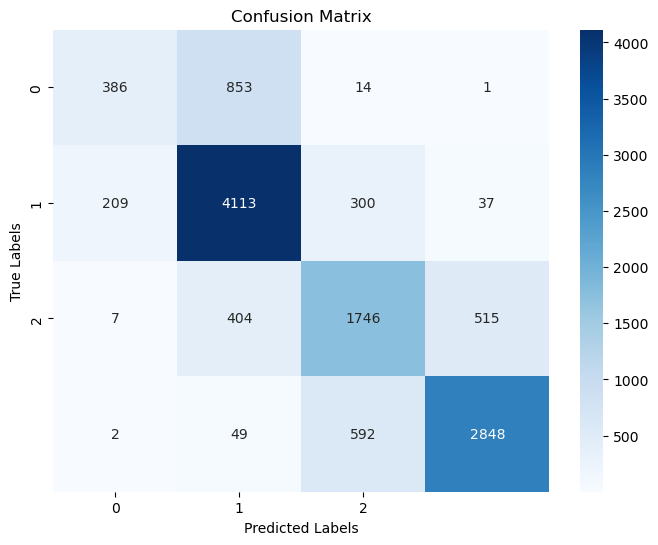

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])


plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")


plt.show()
